Project - MRI Brain Tumor Segementation

## 1. Environment Setup and Configuration

### 1.1. Library Installation & Package Imports

In [1]:
!pip install -q kaggle

In [2]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import mixed_precision

### 1.2.Hardware and Device Verification

In [3]:
# to clear the old graphs and unnecessary memory.
tf.keras.backend.clear_session()

# Checking the avaibality.
print("TensorFlow Version:", tf.__version__)

print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"riyashakyas","key":"89759a4050687c6382c06b548cf8c8c0"}'}

## 2. Data Acquistion & Ingestion

### 2.1. Dataset Acquistion/Downloading

In [5]:
!kaggle datasets download -d briscdataset/brisc2025

Dataset URL: https://www.kaggle.com/datasets/briscdataset/brisc2025
License(s): Attribution 4.0 International (CC BY 4.0)
100% 250M/250M [00:16<00:00, 15.6MB/s]



### 2.2. Archive Extraction

In [6]:
# unzipping the file
with zipfile.ZipFile("brisc2025.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/brisc2025")

### 2.3. Directory Architecture Verification

In [7]:
!ls -l /content/brisc2025/

total 4
drwxr-xr-x 4 root root 4096 Jul 23 13:08 brisc2025


In [8]:
!ls -l /content/brisc2025/brisc2025/

total 12968
drwxr-xr-x 4 root root    4096 Jul 23 13:08 classification_task
-rw-r--r-- 1 root root 4049088 Jul 23 13:08 manifest.csv
-rw-r--r-- 1 root root      80 Jul 23 13:08 manifest.csv.sha256
-rw-r--r-- 1 root root 9206335 Jul 23 13:08 manifest.json
-rw-r--r-- 1 root root      81 Jul 23 13:08 manifest.json.sha256
-rw-r--r-- 1 root root    3737 Jul 23 13:08 README.md
drwxr-xr-x 4 root root    4096 Jul 23 13:08 segmentation_task


In [9]:
!ls -l /content/brisc2025/brisc2025/segmentation_task

total 8
drwxr-xr-x 4 root root 4096 Jul 23 13:08 test
drwxr-xr-x 4 root root 4096 Jul 23 13:08 train


In [10]:
data=tf.keras.utils.image_dataset_from_directory("/content/brisc2025/brisc2025/segmentation_task")

Found 9586 files belonging to 2 classes.


## 3. Exploratory Data Analysis (EDA) & Data Understanding

### 3.1. Data Ingestion and Structural Verification

In [11]:
import os
import cv2

image_dir = '/content/brisc2025/brisc2025/segmentation_task/train/images'
unique_shapes = set()

# 1. Gather all unique shapes from the dataset
for filename in os.listdir(image_dir):
    if filename.endswith(('.png', '.jpg', '.jpeg')):
        path = os.path.join(image_dir, filename)
        img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
        if img is not None:
            unique_shapes.add(img.shape)

# 2. Define ANSI colors for the output highlighting
RED_HIGHLIGHT = "\033[1;31m"  # Bold Red
RESET_COLOR = "\033[0m"       # Back to normal text

# 3. Print the set of shapes with conditional color coding
formatted_shapes = []
for shape in unique_shapes:
    # If the shape is missing the 3rd channel element (length is 2), color it red!
    if len(shape) == 2:
        formatted_shapes.append(f"{RED_HIGHLIGHT}{shape}{RESET_COLOR}")
    else:
        formatted_shapes.append(str(shape))

# Join them all together so they print out exactly like your original list
print("All unique image pixel sizes found in dataset:")
print("{ " + ", ".join(formatted_shapes) + " }")

All unique image pixel sizes found in dataset:
{ (395, 367, 3), (219, 224, 3), (237, 212, 3), (251, 205, 3), (442, 442, 3), (314, 329, 3), (212, 238, 3), (354, 318, 3), (527, 552, 3), (218, 180, 3), (264, 420, 3), (235, 214, 3), (400, 400, 3), (216, 234, 3), (202, 202, 3), (238, 212, 3), (337, 305, 3), (546, 472, 3), (439, 645, 3), (223, 200, 3), (395, 416, 3), (223, 226, 3), (358, 314, 3), (342, 323, 3), (412, 300, 3), (224, 239, 3), (526, 530, 3), (340, 507, 3), (236, 213, 3), (681, 685, 3), (624, 491, 3), (270, 250, 3), (554, 554, 3), (903, 721, 3), (377, 341, 3), (398, 351, 3), (372, 341, 3), (252, 200, 3), (345, 338, 3), (500, 455, 3), (256, 256), (993, 825, 3), (354, 289, 3), (225, 209, 3), (369, 503, 3), (512, 512, 3), (410, 304, 3), (306, 278, 3), (210, 201, 3), (214, 226, 3), (345, 300, 3), (237, 213, 3), (396, 402, 3), (394, 295, 3), (355, 330, 3), (235, 200, 3), (427, 441, 3), (240, 210, 3), (398, 369, 3), (306, 306, 3), (249, 206, 3), (320, 497, 3), (320, 257, 3), (234, 219

In [12]:
# Verify paired path splits match
train_imgs = sorted(os.listdir('/content/brisc2025/brisc2025/segmentation_task/train/images'))
train_msks = sorted(os.listdir('/content/brisc2025/brisc2025/segmentation_task/train/masks'))
print(f"Train Scans: {len(train_imgs)} | Train Masks: {len(train_msks)}")
assert len(train_imgs) == len(train_msks), "Data alignment error between images and masks."

Train Scans: 3933 | Train Masks: 3933


### 3.2. Ground-Truth Masks Alignnent

In [13]:
import matplotlib.pyplot as plt
import cv2
# Load and overlay a sample pair
img = cv2.imread(os.path.join('/content/brisc2025/brisc2025/segmentation_task/train/images', train_imgs[0]), cv2.IMREAD_GRAYSCALE)
msk = cv2.imread(os.path.join('/content/brisc2025/brisc2025/segmentation_task/train/masks', train_msks[0]), cv2.IMREAD_GRAYSCALE)

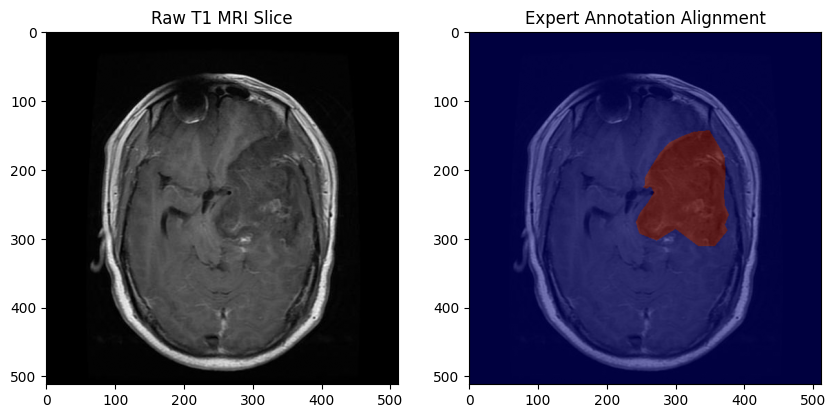

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img, cmap='gray')
ax[0].set_title("Raw T1 MRI Slice")
ax[1].imshow(img, cmap='gray')
ax[1].imshow(msk, cmap='jet', alpha=0.5) # Semitransparent mask overlay
ax[1].set_title("Expert Annotation Alignment")
plt.show()

### 3.3. Target Mask Label Analysis

In [15]:
import numpy as np
# Discover exact numeric representations used in annotations
unique_classes = np.unique(msk)
print(f"Unique pixel values in mask array: {unique_classes}")

Unique pixel values in mask array: [  0   1   2   3   4   5   6   7 248 249 250 251 252 253 254 255]


### 3.4. Spatial Resolution Uniformity Inspection

In [16]:
import os
import cv2

image_dir = '/content/brisc2025/brisc2025/segmentation_task/train/images'
mask_dir = '/content/brisc2025/brisc2025/segmentation_task/train/masks'

unique_img_shapes = set()
unique_msk_shapes = set()

# Scan images
for filename in os.listdir(image_dir):
    if filename.endswith(('.png', '.jpg', '.jpeg')):
        img = cv2.imread(os.path.join(image_dir, filename), cv2.IMREAD_UNCHANGED)
        if img is not None: unique_img_shapes.add(img.shape)

# Scan masks
for filename in os.listdir(mask_dir):
    if filename.endswith(('.png', '.jpg', '.jpeg')):
        msk = cv2.imread(os.path.join(mask_dir, filename), cv2.IMREAD_UNCHANGED)
        if msk is not None: unique_msk_shapes.add(msk.shape)

print(f"Unique Image Sizes found: {unique_img_shapes}\n")
print(f"Unique Mask Sizes found: {unique_msk_shapes}")

Unique Image Sizes found: {(395, 367, 3), (219, 224, 3), (237, 212, 3), (251, 205, 3), (442, 442, 3), (314, 329, 3), (212, 238, 3), (354, 318, 3), (527, 552, 3), (218, 180, 3), (264, 420, 3), (235, 214, 3), (400, 400, 3), (216, 234, 3), (202, 202, 3), (238, 212, 3), (337, 305, 3), (546, 472, 3), (439, 645, 3), (223, 200, 3), (395, 416, 3), (223, 226, 3), (358, 314, 3), (342, 323, 3), (412, 300, 3), (224, 239, 3), (526, 530, 3), (340, 507, 3), (236, 213, 3), (681, 685, 3), (624, 491, 3), (270, 250, 3), (554, 554, 3), (903, 721, 3), (377, 341, 3), (398, 351, 3), (372, 341, 3), (252, 200, 3), (345, 338, 3), (500, 455, 3), (256, 256), (993, 825, 3), (354, 289, 3), (225, 209, 3), (369, 503, 3), (512, 512, 3), (410, 304, 3), (306, 278, 3), (210, 201, 3), (214, 226, 3), (345, 300, 3), (237, 213, 3), (396, 402, 3), (394, 295, 3), (355, 330, 3), (235, 200, 3), (427, 441, 3), (240, 210, 3), (398, 369, 3), (306, 306, 3), (249, 206, 3), (320, 497, 3), (320, 257, 3), (234, 219, 3), (362, 507, 3), (

In [17]:
# Sample matrix size evaluation
print(f"MRI Resolution: {img.shape} | Annotation Mask Resolution: {msk.shape}")

MRI Resolution: (512, 512) | Annotation Mask Resolution: (512, 512)


### 3.5. Anatomical Plane Distribution Analysis

In [18]:
# BRISC format embeds planes in filenames (ax=axial, co=coronal, sa=sagittal)
planes = [name.split('_')[3] for name in train_imgs]
from collections import Counter
print("Anatomical View Breakdown:", Counter(planes))

Anatomical View Breakdown: Counter({'pi': 1457, 'me': 1329, 'gl': 1147})


### 3.6. Class Imbalance Assessment (Background-to-Tumor Ratio)

In [19]:
tumor_pixels = np.count_nonzero(msk)
total_pixels = msk.size
print(f"Tumor-to-Background Volumetric Ratio: {(tumor_pixels / total_pixels) * 100:.3f}%")

Tumor-to-Background Volumetric Ratio: 1.628%


### 3.7. Signal Intensity Profile Distribution

In [20]:
print(f"Intensity Range: Min={img.min()}, Max={img.max()}, Mean={img.mean():.2f}")

Intensity Range: Min=0, Max=255, Mean=40.89


## 4. Data Preprocessing

### 4.1. Global Target Parameter Initialization

In [21]:
image_path="/content/brisc2025/brisc2025/segmentation_task/train/images"
mask_path="/content/brisc2025/brisc2025/segmentation_task/train/masks"

# 1. Spatial Resolution Configuration
IMG_HEIGHT = 256
IMG_WIDTH = 256
NUM_CHANNELS = 1  # Standardized grayscale target depth

# 2. Pipeline Hyperparameters
BATCH_SIZE = 32

# 3. Explicit Data Source Path Infrastructure
# Corrected: Added the extra 'brisc2025' to the path
DATASET_BASE_DIR = '/content/brisc2025/brisc2025/segmentation_task/train'
IMAGE_DIR = os.path.join(DATASET_BASE_DIR, 'images')
MASK_DIR = os.path.join(DATASET_BASE_DIR, 'masks')

print("--- Pipeline Configuration Initialized ---")
print(f"Target Dimensions: {IMG_HEIGHT}x{IMG_WIDTH}x{NUM_CHANNELS}")
print(f"Training Batch Size: {BATCH_SIZE}")

--- Pipeline Configuration Initialized ---
Target Dimensions: 256x256x1
Training Batch Size: 32


### 4.2.File Mapping and Data Pipeline Parsing Function

In [22]:
import cv2
import numpy as np
import tensorflow as tf

def load_and_preprocess_image_pair(img_path, msk_path):
    """Loads a single MRI/Mask pair, fixes channels, resizes, and normalizes."""
    # 1. Force Grayscale read to neutralize 3-channel and 1-channel 'moles'
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    msk = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)

    # 2. Uniform Aspect-Ratio Resizing
    img_resized = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_LINEAR)
    msk_resized = cv2.resize(msk, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_NEAREST)

    # 3. Min-Max Normalization (0-255 -> 0.0-1.0)
    img_normalized = img_resized.astype(np.float32) / 255.0

    # 4. Strict Mask Binarization
    msk_binary = np.where(msk_resized > 0, 1.0, 0.0).astype(np.float32)

    # 5. Expand dimensions to include the mandatory channel axis (H, W, C)
    img_ready = np.expand_dims(img_normalized, axis=-1)
    msk_ready = np.expand_dims(msk_binary, axis=-1)

    return img_ready, msk_ready

# Wrap the python function into a TensorFlow-compatible operator
def tf_parse_wrapper(img_path, msk_path):
    [img, msk] = tf.py_function(lambda p1, p2: load_and_preprocess_image_pair(p1.numpy().decode(), p2.numpy().decode()),
                                [img_path, msk_path], [tf.float32, tf.float32])
    img.set_shape([IMG_HEIGHT, IMG_WIDTH, NUM_CHANNELS])
    msk.set_shape([IMG_HEIGHT, IMG_WIDTH, NUM_CHANNELS])
    return img, msk

### 4.3. Dataset Pipeline Generation

In [23]:
# Gather and sort all individual filenames to guarantee absolute mask alignment
all_img_names = sorted(os.listdir(image_path))
all_msk_names = sorted(os.listdir(mask_path))

# Generate full path lists
all_img_paths = [os.path.join(IMAGE_DIR, name) for name in all_img_names]
all_msk_paths = [os.path.join(MASK_DIR, name) for name in all_msk_names]

# Create the high-performance tf.data object
dataset = tf.data.Dataset.from_tensor_slices((all_img_paths, all_msk_paths))
dataset = dataset.shuffle(buffer_size=len(all_img_paths), seed=42)
dataset = dataset.map(tf_parse_wrapper, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.batch(BATCH_SIZE)
dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

print(f"Successfully constructed tensor data stream grouped into batches of {BATCH_SIZE}!")

Successfully constructed tensor data stream grouped into batches of 32!


### 4.4. Preprocessing Pipeline Visual Verification

Processed Batch Image Shape: (32, 256, 256, 1)
Processed Batch Mask Shape: (32, 256, 256, 1)


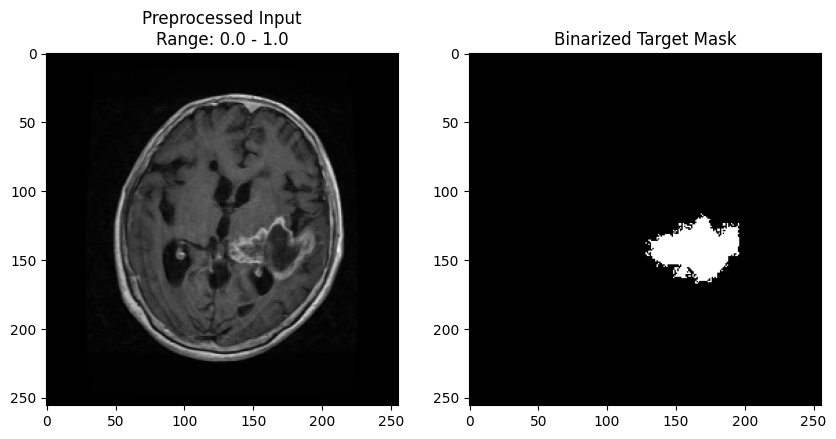

In [24]:
import matplotlib.pyplot as plt

# Pull one batch out of our preprocessed pipeline
for sample_img_batch, sample_msk_batch in dataset.take(1):
    print(f"Processed Batch Image Shape: {sample_img_batch.shape}") # Expecting (32, 256, 256, 1)
    print(f"Processed Batch Mask Shape: {sample_msk_batch.shape}")   # Expecting (32, 256, 256, 1)

    # Display the first image from this batch
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(sample_img_batch[0, :, :, 0], cmap='gray')
    ax[0].set_title(f"Preprocessed Input\nRange: {sample_img_batch[0].numpy().min():.1f} - {sample_img_batch[0].numpy().max():.1f}")
    ax[1].imshow(sample_msk_batch[0, :, :, 0], cmap='gray')
    ax[1].set_title("Binarized Target Mask")
    plt.show()

### 4.5. Splitting Data

In [25]:
import os
image_files = sorted(
    os.listdir(image_path)
)

image_mask_pairs = []

for img_file in image_files:

    base_name = os.path.splitext(
        img_file
    )[0]

    mask_file = base_name + ".png"

    image_full_path = os.path.join(
        image_path,
        img_file
    )

    mask_full_path = os.path.join(
        mask_path,
        mask_file
    )

    if os.path.exists(mask_full_path):

        image_mask_pairs.append(
            (
                image_full_path,
                mask_full_path
            )
        )

print("Total Valid Pairs:",
      len(image_mask_pairs))


Total Valid Pairs: 3933


In [26]:
train_pairs, val_pairs = train_test_split(

    image_mask_pairs,

    test_size=0.2,

    random_state=42,

    shuffle=True
)

print("Training Samples:",
      len(train_pairs))

print("Validation Samples:",
      len(val_pairs))

Training Samples: 3146
Validation Samples: 787


## 5. Model Development And Architecture

### 5.1. U-Net Architecture

In [34]:
import tensorflow as tf

# 1. Unzip the tuple pairs back into separate image path and mask path lists
X_train_paths, y_train_paths = zip(*train_pairs)
X_val_paths, y_val_paths     = zip(*val_pairs)

# 2. Convert them into high-performance tf.data pipelines
train_dataset = tf.data.Dataset.from_tensor_slices((list(X_train_paths), list(y_train_paths)))
val_dataset   = tf.data.Dataset.from_tensor_slices((list(X_val_paths), list(y_val_paths)))

# 3. Batch, shuffle, and optimize memory streams using your global variables
train_dataset = train_dataset.map(tf_parse_wrapper, num_parallel_calls=tf.data.AUTOTUNE).shuffle(buffer_size=100, seed=42).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset   = val_dataset.map(tf_parse_wrapper, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import tensorflow.keras.backend as K
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# =========================================================================
# 1. OPTIMIZATION OBJECTIVES & METRICS (Dice Loss Core)
# =========================================================================
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """Calculates spatial target overlap, ignoring uninformative background spaces."""
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    """Loss optimization engine designed to address the 6.54% structural class imbalance."""
    return 1.0 - dice_coefficient(y_true, y_pred)

print(dice_coefficient)
print(dice_loss)

<function dice_coefficient at 0x790cae344680>
<function dice_loss at 0x790cae344cc0>


In [ ]:
# # =========================================================================
# # 2. STANDARD U-NET STRUCTURAL GRAPH
# # =========================================================================
# def build_standard_unet(input_shape=(256, 256, 1)):
#     inputs = layers.Input(input_shape)

#     # --- ENCODER (Downsampling Context Engine) ---
#     c1 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
#     c1 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(c1)
#     p1 = layers.MaxPooling2D((2, 2))(c1)

#     c2 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(p1)
#     c2 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c2)
#     p2 = layers.MaxPooling2D((2, 2))(c2)

#     # --- ARCHITECTURAL BOTTLE-NECK ---
#     c3 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p2)
#     c3 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c3)

#     # --- DECODER (Upsampling Localization Engine) ---
#     u4 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c3)
#     u4 = layers.concatenate([u4, c2]) # Skip Connection passing sharp spatial boundaries
#     c4 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u4)
#     c4 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c4)

#     u5 = layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c4)
#     u5 = layers.concatenate([u5, c1]) # Skip Connection passing original crisp shapes
#     c5 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(u5)
#     c5 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(c5)

#     # Output projection layer utilizing sigmoid bounds for semantic binary probability mapping
#     outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c5)

#     return Model(inputs=[inputs], outputs=[outputs], name="Standard_U-Net_Baseline")

In [ ]:
# =========================================================================
# 2. STANDARD U-NET STRUCTURAL GRAPH
# =========================================================================
def build_standard_unet(input_shape=(256, 256, 1)):
    inputs = layers.Input(input_shape)

    # --- ENCODER (Downsampling Context Engine) ---
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # --- ARCHITECTURAL BOTTLE-NECK ---
    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c3)

    # --- DECODER (Upsampling Localization Engine) ---
    u4 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c3)
    u4 = layers.concatenate([u4, c2]) # Skip Connection passing sharp spatial boundaries
    c4 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u4)
    c4 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c4)

    u5 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c4)
    u5 = layers.concatenate([u5, c1]) # Skip Connection passing original crisp shapes
    c5 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c5)

    # Output projection layer utilizing sigmoid bounds for semantic binary probability mapping
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c5)

    return Model(inputs=[inputs], outputs=[outputs], name="Standard_U-Net_Baseline")

In [ ]:
# =========================================================================
# 3. COMPILATION AND INITIALIZATION
# =========================================================================
# Build model with shapes pulled directly from your Section 4 global settings
baseline_unet = build_standard_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, NUM_CHANNELS))

baseline_unet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=dice_loss,
    metrics=[dice_coefficient, 'accuracy']
)


In [ ]:
# =========================================================================
# 4. TRAINING GUARDIANS (Callbacks)
# =========================================================================
callbacks = [
    # Secures the best performing validation weights during training iterations
    ModelCheckpoint('best_baseline_unet.keras', monitor='val_loss', save_best_only=True, verbose=1),

    # Halts training if validation metrics cease to improve after 7 consecutive epochs
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),

    # Decelerates learning rate steps upon performance plateauing
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]


In [ ]:
# =========================================================================
# 5. EXECUTION LOOP
# =========================================================================
print("\n Commencing Baseline Standard U-Net Training Workflow...\n")

history_u_net = baseline_unet.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)



 Commencing Baseline Standard U-Net Training Workflow...

Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 0.1585 - dice_coefficient: 0.0397 - loss: 0.9603
Epoch 1: val_loss improved from None to 0.92406, saving model to best_baseline_unet.keras

Epoch 1: finished saving model to best_baseline_unet.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 120s 805ms/step - accuracy: 0.3424 - dice_coefficient: 0.0458 - loss: 0.9544 - val_accuracy: 0.6487 - val_dice_coefficient: 0.0759 - val_loss: 0.9241 - learning_rate: 1.0000e-04
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.9357 - dice_coefficient: 0.0221 - loss: 0.9779
Epoch 2: val_loss did not improve from 0.92406
99/99 ━━━━━━━━━━━━━━━━━━━━ 52s 518ms/step - accuracy: 0.9710 - dice_coefficient: 0.0060 - loss: 0.9940 - val_accuracy: 0.9815 - val_dice_coefficient: 5.7814e-11 - val_loss: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.9810 - dice_coefficient: 5.6934e-11 - l

Data Visulaization for U-Net Architecture

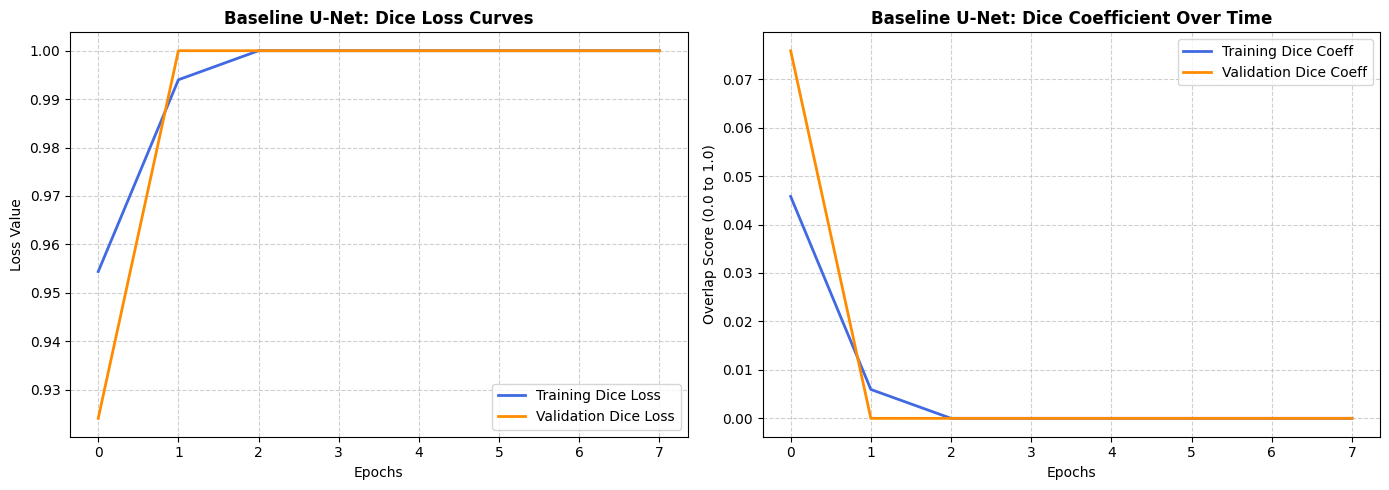

In [ ]:
import matplotlib.pyplot as plt

# Create a figure canvas
plt.figure(figsize=(14, 5))

# --- Plot 1: Dice Loss ---
plt.subplot(1, 2, 1)
plt.plot(history_u_net.history['loss'], label='Training Dice Loss', color='royalblue', lw=2)
plt.plot(history_u_net.history['val_loss'], label='Validation Dice Loss', color='darkorange', lw=2)
plt.title('Baseline U-Net: Dice Loss Curves', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: Dice Coefficient ---
plt.subplot(1, 2, 2)
plt.plot(history_u_net.history['dice_coefficient'], label='Training Dice Coeff', color='royalblue', lw=2)
# FIX: Swapped 'val_loss' to 'val_dice_coefficient' to accurately map validation scores
plt.plot(history_u_net.history['val_dice_coefficient'], label='Validation Dice Coeff', color='darkorange', lw=2)
plt.title('Baseline U-Net: Dice Coefficient Over Time', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Overlap Score (0.0 to 1.0)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

5.2. U-NET Architecture with Data Augmentation

In [ ]:
import tensorflow as tf

# =========================================================================
# A. DUAL-TRANSFORMATION AUGMENTATION ENGINE
# =========================================================================
def augment_pair(image, mask):
    """
    Applies image-intensity transformations ONLY to the MRI scan,
    preserving the strict anatomical orientation and the target mask.
    """
    # 1. Random Contrast Adjustment (Simulates variance in MRI machine calibrations)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)

    # 2. Random Brightness Adjustment (Simulates variance in scanning intensities)
    image = tf.image.random_brightness(image, max_delta=0.1)

    # 3. Safety Check: Guarantee absolute bounding limits
    # (MRI Pixels must stay between 0 and 1; Masks must remain strictly binary 0 or 1)
    image = tf.clip_by_value(image, 0.0, 1.0)
    mask = tf.cast(mask > 0.5, tf.float32)

    return image, mask

✅ Section 5.2.1: Augmented Training Pipeline Successfully Initialized!


In [ ]:

# =========================================================================
# B. GENERATE THE DYNAMIC STREAMING PIPELINE
# =========================================================================
# Extract raw paths from your existing 80% train split
X_train_paths, y_train_paths = zip(*train_pairs)

train_dataset_augmented = tf.data.Dataset.from_tensor_slices((list(X_train_paths), list(y_train_paths)))

# Sequence: Load paths -> Preprocess -> Dynamically Augment -> Batch & Prefetch
train_dataset_augmented = (train_dataset_augmented
    .map(tf_parse_wrapper, num_parallel_calls=tf.data.AUTOTUNE)
    .map(augment_pair, num_parallel_calls=tf.data.AUTOTUNE)  # Intensity adjustments happen here on-the-fly
    .shuffle(buffer_size=100, seed=42)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))

print("✅ Section 5.2.1: Augmented Training Pipeline Successfully Initialized!")

In [ ]:
# 1. Build a fresh copy of the U-Net graph
augmented_unet = build_standard_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, NUM_CHANNELS))

# 2. Compile under strict control settings
augmented_unet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=dice_loss,
    metrics=[dice_coefficient, 'accuracy']
)

# 3. Setup Callbacks (Clean, spaced layout)
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_augmented_unet_model.h5",
        monitor='val_loss',
        save_best_only=True
    )

]




🚀 Commencing Augmented U-Net Training Workflow...

Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.3671 - dice_coefficient: 0.0379 - loss: 0.9621

99/99 ━━━━━━━━━━━━━━━━━━━━ 68s 619ms/step - accuracy: 0.3185 - dice_coefficient: 0.0402 - loss: 0.9599 - val_accuracy: 0.6408 - val_dice_coefficient: 0.0539 - val_loss: 0.9461 - learning_rate: 1.0000e-04
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.8883 - dice_coefficient: 0.1274 - loss: 0.8726

99/99 ━━━━━━━━━━━━━━━━━━━━ 54s 537ms/step - accuracy: 0.9383 - dice_coefficient: 0.1589 - loss: 0.8419 - val_accuracy: 0.9535 - val_dice_coefficient: 0.2169 - val_loss: 0.7826 - learning_rate: 1.0000e-04
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 54s 544ms/step - accuracy: 0.9595 - dice_coefficient: 0.1838 - loss: 0.8154 - val_accuracy: 0.9792 - val_dice_coefficient: 0.1510 - val_loss: 0.8492 - learning_rate: 1.0000e-04
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.9683 - dice_coefficient: 0.2256 - loss: 0.7744

99/99 ━━━━━━━━━━━━━━━━━━━━ 55s 548ms/step - accuracy: 0.9682 - dice_coefficient: 0.2138 - loss: 0.7868 - val_accuracy: 0.9689 - val_dice_coefficient: 0.2638 - val_loss: 0.7360 - learning_rate: 1.0000e-04
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 61s 611ms/step - accuracy: 0.9651 - dice_coefficient: 0.2164 - loss: 0.7833 - val_accuracy: 0.9785 - val_dice_coefficient: 0.2309 - val_loss: 0.7692 - learning_rate: 1.0000e-04
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.9686 - dice_coefficient: 0.2577 - loss: 0.7423

99/99 ━━━━━━━━━━━━━━━━━━━━ 55s 557ms/step - accuracy: 0.9691 - dice_coefficient: 0.2466 - loss: 0.7535 - val_accuracy: 0.9740 - val_dice_coefficient: 0.2801 - val_loss: 0.7197 - learning_rate: 1.0000e-04
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 57s 565ms/step - accuracy: 0.9678 - dice_coefficient: 0.2382 - loss: 0.7615 - val_accuracy: 0.9792 - val_dice_coefficient: 0.2360 - val_loss: 0.7642 - learning_rate: 1.0000e-04
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.9701 - dice_coefficient: 0.2631 - loss: 0.7369

99/99 ━━━━━━━━━━━━━━━━━━━━ 58s 581ms/step - accuracy: 0.9709 - dice_coefficient: 0.2611 - loss: 0.7386 - val_accuracy: 0.9702 - val_dice_coefficient: 0.3022 - val_loss: 0.6977 - learning_rate: 1.0000e-04
Epoch 9/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.9663 - dice_coefficient: 0.2600 - loss: 0.7400

99/99 ━━━━━━━━━━━━━━━━━━━━ 54s 547ms/step - accuracy: 0.9690 - dice_coefficient: 0.2595 - loss: 0.7404 - val_accuracy: 0.9748 - val_dice_coefficient: 0.3045 - val_loss: 0.6952 - learning_rate: 1.0000e-04
Epoch 10/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.9730 - dice_coefficient: 0.2988 - loss: 0.7012

99/99 ━━━━━━━━━━━━━━━━━━━━ 55s 548ms/step - accuracy: 0.9732 - dice_coefficient: 0.2921 - loss: 0.7087 - val_accuracy: 0.9764 - val_dice_coefficient: 0.3289 - val_loss: 0.6709 - learning_rate: 1.0000e-04
Epoch 11/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 55s 552ms/step - accuracy: 0.9743 - dice_coefficient: 0.3069 - loss: 0.6938 - val_accuracy: 0.9807 - val_dice_coefficient: 0.3153 - val_loss: 0.6841 - learning_rate: 1.0000e-04
Epoch 12/50
83/99 ━━━━━━━━━━━━━━━━━━━━ 7s 494ms/step - accuracy: 0.9746 - dice_coefficient: 0.3242 - loss: 0.6758

In [ ]:
# 4. Training Loop Execution
print("\n🚀 Commencing Augmented U-Net Training Workflow...\n")

history_augmented_unet = augmented_unet.fit(
    train_dataset_augmented,
    validation_data=val_dataset,
    epochs=50,
    callbacks=callbacks
)

print("\n✅ Execution Finished! File saved to 'best_augmented_unet_model.h5'.")

In [ ]:
import tensorflow as tf

def augment_pair(image, mask):
    # 1. Intensity Augmentations (Simulating variations in MRI machine calibrations)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_brightness(image, max_delta=0.1)

    # 2. Strict Boundary Processing & Value Clipping
    image = tf.clip_by_value(image, 0.0, 1.0)
    mask = tf.cast(mask > 0.5, tf.float32)

    return image, mask

# Unpack your 80% training set pairs path strings
X_train_paths, y_train_paths = zip(*train_pairs)

train_dataset_augmented = tf.data.Dataset.from_tensor_slices((list(X_train_paths), list(y_train_paths)))

train_dataset_augmented = (train_dataset_augmented
    .map(tf_parse_wrapper, num_parallel_calls=tf.data.AUTOTUNE)
    .map(augment_pair, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(buffer_size=100, seed=42)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))

print("✅ Augmented training stream initialized!")

In [ ]:
import matplotlib.pyplot as plt

# 1. Initialize the plot canvas
plt.figure(figsize=(14, 5))


# =========================================================================
# PLOT 1: AUGMENTED DICE LOSS CURVES
# =========================================================================
plt.subplot(1, 2, 1)

plt.plot(
    history_augmented_unet.history['loss'],
    label='Training Dice Loss (Augmented)',
    color='forestgreen',
    lw=2
)

plt.plot(
    history_augmented_unet.history['val_loss'],
    label='Validation Dice Loss',
    color='crimson',
    lw=2
)

plt.title('Augmented U-Net: Dice Loss Curves', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)


# =========================================================================
# PLOT 2: AUGMENTED DICE COEFFICIENT OVER TIME
# =========================================================================
plt.subplot(1, 2, 2)

plt.plot(
    history_augmented_unet.history['dice_coefficient'],
    label='Training Dice Coeff (Augmented)',
    color='forestgreen',
    lw=2
)

plt.plot(
    history_augmented_unet.history['val_dice_coefficient'],
    label='Validation Dice Coeff',
    color='crimson',
    lw=2
)

plt.title('Augmented U-Net: Dice Coefficient Over Time', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Overlap Score (0.0 to 1.0)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)


# =========================================================================
# DISPLAY GRAPH PACKAGING
# =========================================================================
plt.tight_layout()
plt.show()

5.3. Comparision between U-net and U-Net with data augmentation

In [ ]:
import matplotlib.pyplot as plt

# 1. Initialize a unified comparative canvas
plt.figure(figsize=(15, 6))


# =========================================================================
# COMPARATIVE PLOT 1: BASELINE VS. AUGMENTED DICE LOSS
# =========================================================================
plt.subplot(1, 2, 1)

# Section 5.1 Baseline Curves
plt.plot(
    history_u_net.history['val_loss'],
    label='5.1 Baseline Validation Loss',
    color='darkorange',
    linestyle='--',
    lw=2
)

# Section 5.2 Augmented Curves
plt.plot(
    history_augmented_unet.history['val_loss'],
    label='5.2 Augmented Validation Loss',
    color='crimson',
    linestyle='-',
    lw=2
)

plt.title('Validation Loss Convergence Comparison', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Dice Loss Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)


# =========================================================================
# COMPARATIVE PLOT 2: BASELINE VS. AUGMENTED DICE COEFFICIENT
# =========================================================================
plt.subplot(1, 2, 2)

# Section 5.1 Baseline Curves
plt.plot(
    history_u_net.history['val_dice_coefficient'],
    label='U-Net architecture Baseline Validation Dice',
    color='royalblue',
    linestyle='--',
    lw=2
)

# Section 5.2 Augmented Curves
plt.plot(
    history_augmented_unet.history['val_dice_coefficient'],
    label='U-Net with Data Augmented Validation Dice',
    color='forestgreen',
    linestyle='-',
    lw=2
)

plt.title('Validation Overlap Score Comparison (Dice)', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Overlap Score (0.0 to 1.0)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)


# =========================================================================
# DISPLAY PACKAGING
# =========================================================================
plt.tight_layout()
plt.show()

### 5.3. Attention U-Net Architecture

In [27]:
import tensorflow as tf

# Re-extract clean paths from your original 80% train split
X_train_paths, y_train_paths = zip(*train_pairs)

train_dataset_clean = tf.data.Dataset.from_tensor_slices((list(X_train_paths), list(y_train_paths)))

# Sequence: Load paths -> Preprocess -> Batch & Prefetch (No augmentation noise!)
train_dataset_clean = (train_dataset_clean
    .map(tf_parse_wrapper, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(buffer_size=100, seed=42)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))

print("✅ Clean, original training pipeline restored for the Attention U-Net test!")

✅ Clean, original training pipeline restored for the Attention U-Net test!


In [28]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import tensorflow.keras.backend as K

# =========================================================================
# 1. THE ATTENTION GATE BLOCK
# =========================================================================
def attention_gate(x, gating_signal, inter_shape):
    """
    Suppresses irrelevant background regions and highlights tumor zones.
    x: Skip connection feature map from the encoder.
    gating_signal: Lower resolution feature map from the deeper layer decoder.
    """
    # Align the channels of both streams
    theta_x = layers.Conv2D(inter_shape, (1, 1), strides=(1, 1), padding='same')(x)

    phi_g = layers.Conv2D(inter_shape, (1, 1), strides=(1, 1), padding='same')(gating_signal)

    # Upsample the gating signal to match spatial dimensions of the encoder layer
    phi_g_upsampled = layers.Conv2DTranspose(
        inter_shape, (2, 2),
        strides=(2, 2),
        padding='same'
    )(phi_g)

    # Combine signals and pass through activation functions to compute attention coefficients
    concat_xg = layers.add([theta_x, phi_g_upsampled])
    act_xg = layers.Activation('relu')(concat_xg)

    psi = layers.Conv2D(1, (1, 1), padding='same')(act_xg)
    sigmoid_psi = layers.Activation('sigmoid')(psi)

    # Multiply the input skip connection by the computed attention coefficients
    return layers.multiply([x, sigmoid_psi])


In [29]:
# =========================================================================
# 2. STRUCTURAL ATTENTION U-NET GRAPH
# =========================================================================
def build_attention_unet(input_shape=(256, 256, 1)):
    inputs = layers.Input(input_shape)

    # --- ENCODER (Downsampling) ---
    c1 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # --- BOTTLE-NECK ---
    c3 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c3)

    # --- DECODER WITH ATTENTION GATES (Upsampling) ---
    # Layer 4 Attention Filtering
    attn2 = attention_gate(x=c2, gating_signal=c3, inter_shape=32)
    u4 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c3)
    u4 = layers.concatenate([u4, attn2]) # Concatenating filtered features instead of raw ones!
    c4 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u4)
    c4 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c4)

    # Layer 5 Attention Filtering
    attn1 = attention_gate(x=c1, gating_signal=c4, inter_shape=16)
    u5 = layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c4)
    u5 = layers.concatenate([u5, attn1])
    c5 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(c5)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c5)

    return Model(inputs=[inputs], outputs=[outputs], name="Attention_U-Net")

In [31]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import tensorflow.keras.backend as K

# =========================================================================
# 1. OPTIMIZATION OBJECTIVES & METRICS (Dice Loss Core)
# =========================================================================
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """Calculates spatial target overlap, ignoring uninformative background spaces."""
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    """Loss optimization engine designed to address the 6.54% structural class imbalance."""
    return 1.0 - dice_coefficient(y_true, y_pred)

# =========================================================================
# 3. COMPILATION CONTROLS WITH SMOOTH STABILIZATION
# =========================================================================
attention_model = build_attention_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, NUM_CHANNELS))

attention_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5), # Stable learning rate
    loss=dice_loss,
    metrics=[dice_coefficient, 'accuracy']
)

In [32]:
# =========================================================================
# 4. HOOKING CALLBACKS STYLE
# =========================================================================
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_attention_unet_model.h5",
        monitor='val_loss',
        save_best_only=True
    )

]


In [35]:

# =========================================================================
# 5. EXECUTE TRAINING LOOP
# =========================================================================
print("\n🚀 Commencing Section 5.3 Attention U-Net Training Workflow...\n")

history_5_3 = attention_model.fit(
    train_dataset_clean,       # Passing clean, un-augmented dataset
    validation_data=val_dataset,
    epochs=50,
    callbacks=callbacks
)

print("\n✅ Attention U-Net training complete! Model saved to 'best_attention_unet_model.h5'.")


🚀 Commencing Section 5.3 Attention U-Net Training Workflow...

Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.4733 - dice_coefficient: 0.0363 - loss: 0.9637

99/99 ━━━━━━━━━━━━━━━━━━━━ 91s 589ms/step - accuracy: 0.3125 - dice_coefficient: 0.0354 - loss: 0.9647 - val_accuracy: 0.3974 - val_dice_coefficient: 0.0361 - val_loss: 0.9638 - learning_rate: 5.0000e-05
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.3491 - dice_coefficient: 0.0400 - loss: 0.9600

99/99 ━━━━━━━━━━━━━━━━━━━━ 34s 343ms/step - accuracy: 0.3501 - dice_coefficient: 0.0422 - loss: 0.9579 - val_accuracy: 0.4484 - val_dice_coefficient: 0.0474 - val_loss: 0.9525 - learning_rate: 5.0000e-05
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.5936 - dice_coefficient: 0.0606 - loss: 0.9394

99/99 ━━━━━━━━━━━━━━━━━━━━ 35s 351ms/step - accuracy: 0.7562 - dice_coefficient: 0.0939 - loss: 0.9065 - val_accuracy: 0.9737 - val_dice_coefficient: 0.1996 - val_loss: 0.8002 - learning_rate: 5.0000e-05
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.9642 - dice_coefficient: 0.2253 - loss: 0.7747

99/99 ━━━━━━━━━━━━━━━━━━━━ 36s 362ms/step - accuracy: 0.9651 - dice_coefficient: 0.2239 - loss: 0.7762 - val_accuracy: 0.9721 - val_dice_coefficient: 0.2268 - val_loss: 0.7731 - learning_rate: 5.0000e-05
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.9654 - dice_coefficient: 0.2406 - loss: 0.7594

...

99/99 ━━━━━━━━━━━━━━━━━━━━ 35s 355ms/step - accuracy: 0.9752 - dice_coefficient: 0.3291 - loss: 0.6709 - val_accuracy: 0.9754 - val_dice_coefficient: 0.3177 - val_loss: 0.6820 - learning_rate: 2.5000e-05
Epoch 43/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 35s 347ms/step - accuracy: 0.9741 - dice_coefficient: 0.3288 - loss: 0.6712 - val_accuracy: 0.9774 - val_dice_coefficient: 0.3167 - val_loss: 0.6831 - learning_rate: 2.5000e-05
Epoch 44/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 35s 348ms/step - accuracy: 0.9752 - dice_coefficient: 0.3321 - loss: 0.6681 - val_accuracy: 0.9779 - val_dice_coefficient: 0.3163 - val_loss: 0.6834 - learning_rate: 2.5000e-05
Epoch 45/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.9751 - dice_coefficient: 0.3359 - loss: 0.6641

99/99 ━━━━━━━━━━━━━━━━━━━━ 35s 351ms/step - accuracy: 0.9753 - dice_coefficient: 0.3330 - loss: 0.6672 - val_accuracy: 0.9753 - val_dice_coefficient: 0.3234 - val_loss: 0.6762 - learning_rate: 2.5000e-05
Epoch 46/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 35s 351ms/step - accuracy: 0.9751 - dice_coefficient: 0.3324 - loss: 0.6675 - val_accuracy: 0.9782 - val_dice_coefficient: 0.3188 - val_loss: 0.6809 - learning_rate: 2.5000e-05
Epoch 47/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.9750 - dice_coefficient: 0.3398 - loss: 0.6602

99/99 ━━━━━━━━━━━━━━━━━━━━ 35s 353ms/step - accuracy: 0.9755 - dice_coefficient: 0.3358 - loss: 0.6639 - val_accuracy: 0.9745 - val_dice_coefficient: 0.3247 - val_loss: 0.6749 - learning_rate: 2.5000e-05
Epoch 48/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 37s 365ms/step - accuracy: 0.9755 - dice_coefficient: 0.3351 - loss: 0.6637 - val_accuracy: 0.9715 - val_dice_coefficient: 0.3181 - val_loss: 0.6813 - learning_rate: 2.5000e-05
Epoch 49/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.9746 - dice_coefficient: 0.3426 - loss: 0.6574

99/99 ━━━━━━━━━━━━━━━━━━━━ 35s 347ms/step - accuracy: 0.9757 - dice_coefficient: 0.3378 - loss: 0.6618 - val_accuracy: 0.9759 - val_dice_coefficient: 0.3288 - val_loss: 0.6707 - learning_rate: 2.5000e-05
Epoch 50/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.9755 - dice_coefficient: 0.3436 - loss: 0.6564

99/99 ━━━━━━━━━━━━━━━━━━━━ 37s 370ms/step - accuracy: 0.9757 - dice_coefficient: 0.3425 - loss: 0.6572 - val_accuracy: 0.9746 - val_dice_coefficient: 0.3294 - val_loss: 0.6701 - learning_rate: 2.5000e-05

✅ Attention U-Net training complete! Model saved to 'best_attention_unet_model.h5'.


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# --- Plot 1: Attention Dice Loss ---
plt.subplot(1, 2, 1)
plt.plot(history_5_3.history['loss'], label='Training Loss (Attention)', color='darkviolet', lw=2)
plt.plot(history_5_3.history['val_loss'], label='Validation Loss (Attention)', color='deeppink', lw=2)
plt.title('Attention U-Net: Dice Loss Curves', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: Attention Dice Coefficient ---
plt.subplot(1, 2, 2)
plt.plot(history_5_3.history['dice_coefficient'], label='Training Dice (Attention)', color='darkviolet', lw=2)
plt.plot(history_5_3.history['val_dice_coefficient'], label='Validation Dice (Attention)', color='deeppink', lw=2)
plt.title('Attention U-Net: Dice Coefficient Over Time', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Overlap Score (0.0 to 1.0)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()